In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random as rnd
import time as t
import os 
import sys
import pandas as pd
print(f"imported at: {t.ctime()}")

import rdkit
from rdkit import Chem
from rdkit.Chem.Descriptors import ExactMolWt
from rdkit.Chem.Crippen import MolLogP
from rdkit.Chem.rdMolDescriptors import CalcTPSA

# rdkitdraw
from rdkit.Chem import Draw
import py3Dmol as dmol
from rdkit.Chem import AllChem,Descriptors,Draw

from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit import DataStructs

imported at: Fri Feb 20 12:07:37 2026


    train_loss  test_loss       lr
0     1.335622   0.875743  0.00001
1     0.957818   0.777270  0.00001
2     0.867936   0.714431  0.00001
3     0.813769   0.670276  0.00001
4     0.776819   0.638616  0.00001
..         ...        ...      ...
95    0.389140   0.311040  0.00001
96    0.388416   0.310506  0.00001
97    0.387177   0.309822  0.00001
98    0.386552   0.308630  0.00001
99    0.385269   0.308803  0.00001

[100 rows x 3 columns]


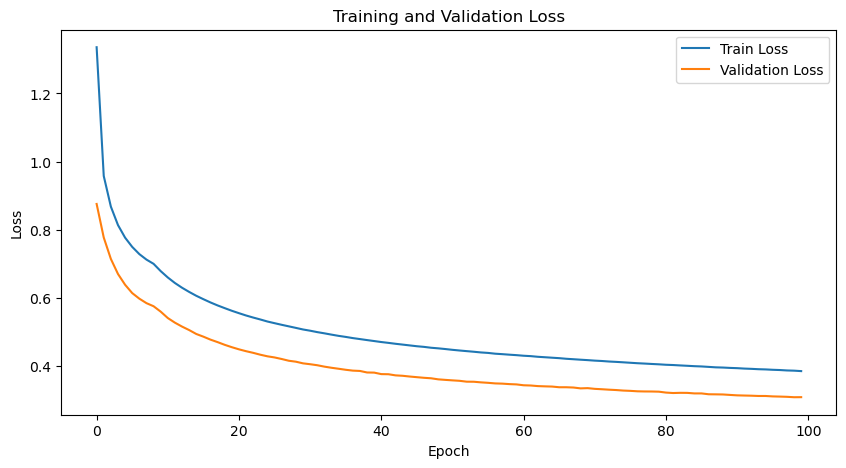

In [4]:
save_folder = "save/"
run_name = "run_20260219_230438"
file = "history.csv"

df = pd.read_csv(save_folder+run_name+"/"+file)
print(df)

def plot_history(df:pd.DataFrame, save_folder:str, file:str):
    x = np.linspace(0, len(df)-1, len(df))
    plt.figure(figsize=(10, 5))
    plt.plot(x, df['train_loss'], label='Train Loss')
    plt.plot(x, df['test_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')


    plt.savefig(save_folder + run_name + "/history_plot.png")
    plt.show()


plot_history(df, save_folder, file)



In [5]:
resultant_path = 'CVAE_transformer_300k_test.txt'

# first column is smiles,
# second column is: MW, third column is LogP

train_path = '250k_zinc_clean.txt'

def read_train_file(train_path:str):
    smiles_list = []
    properties_list = []
    
    with open(train_path, 'r') as file:
        for line in file:
            parts = line.strip().split()
            if len(parts) >= 3:
                smiles_list.append(parts[0])
                properties_list.append((float(parts[1]), float(parts[2])))  # Assuming MW and LogP are in the second and third columns
    
    return smiles_list, properties_list

def read_resultant_file(resultant_path:str):
    """
    This file has column headers, so we need to skip the first line when reading the file.
    The first column is SMILES, the second column is MW, and the third column is LogP.
    
    """
    gen_smiles = []
    gen_properties = []
    
    with open(resultant_path, 'r') as file:
        first_line = True
        #for line in file:
        #    parts = line.strip().split()
        #    if first_line:
        #        first_line = False
        #        continue  # Skip the header line
        #    if len(parts) >= 3:
        #        gen_smiles.append(parts[0])
        #        gen_properties.append((float(parts[1]), float(parts[2])))  # Assuming MW and LogP are in the second and third columns
        # just print all results:
        
        first_line = True
        for line in file:
            if first_line:
                first_line = False
                continue  # Skip the header line
            #print(line.strip())
            # split at ','
            parts = line.strip().split(',')
            if len(parts) >= 3:
                gen_smiles.append(parts[0])
                gen_properties.append((float(parts[1]), float(parts[2])))  # Assuming MW and LogP are in the second and third columns
        
    return gen_smiles, gen_properties

smiles_list, properties_list = read_train_file(train_path)
#

#NOTE: df_train has the training data, with columns: smiles, MW, LogP
df_train = pd.DataFrame({
    'smiles': smiles_list,
    'MW': [prop[0] for prop in properties_list],
    'LogP': [prop[1] for prop in properties_list]
})



gen_smiles, gen_prop = read_resultant_file(resultant_path)
gen_df = pd.DataFrame({
    'smiles': gen_smiles,
    'MW': [prop[0] for prop in gen_prop],
    'LogP': [prop[1] for prop in gen_prop]
})



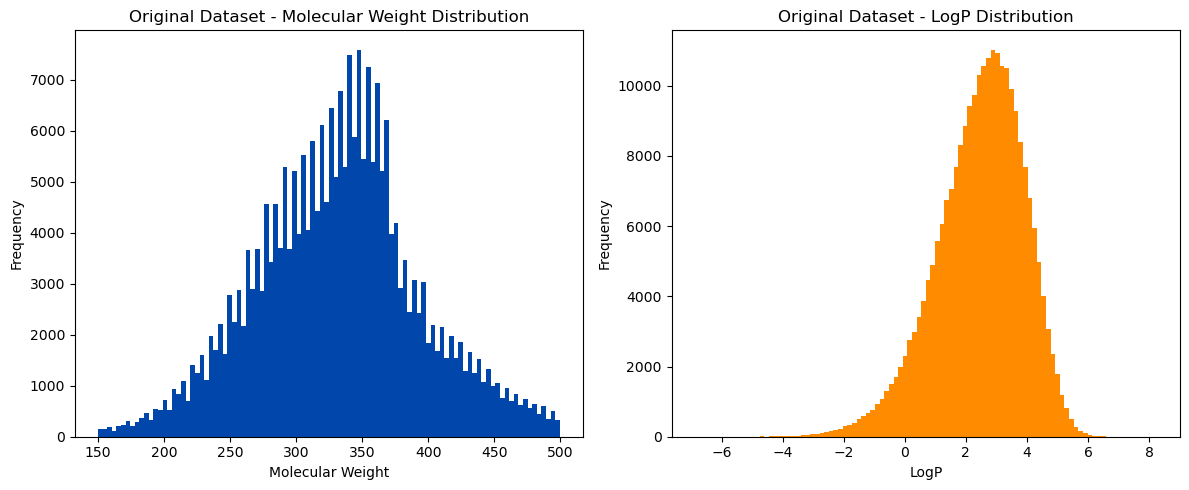

Generated Dataset:


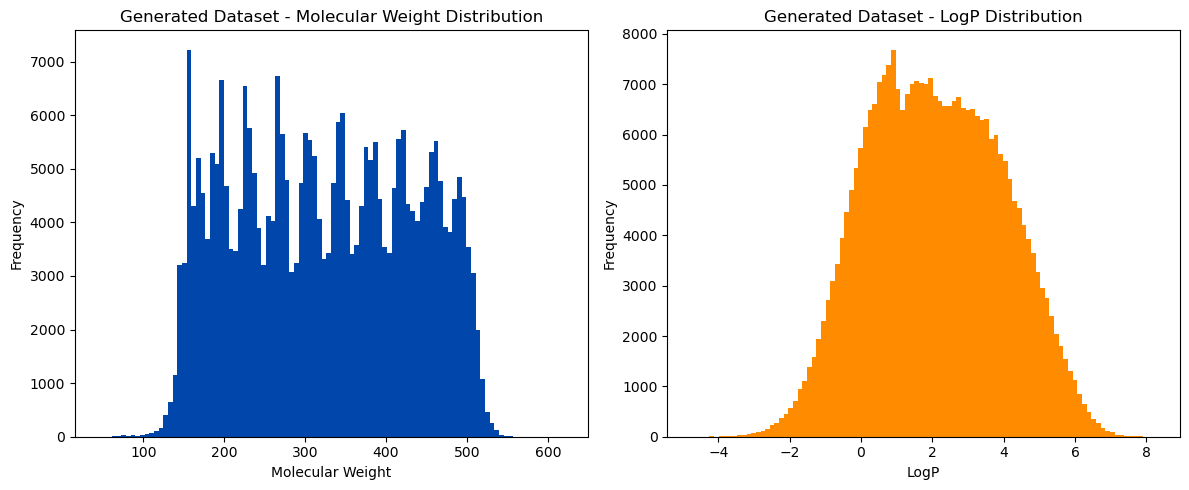

In [6]:
def plot_prop_distribution(df:pd.DataFrame, save_folder:str,top_title_str:str="Property Distribution"):
    plt.figure(figsize=(12, 5))

    nice_blue = '#0046AB'
    nice_orange = '#FF8C00'

    plt.subplot(1, 2, 1)
    plt.hist(df['MW'], bins=100, alpha=1.0, color=nice_blue)
    plt.title(top_title_str + ' - Molecular Weight Distribution')
    plt.xlabel('Molecular Weight')
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    plt.hist(df['LogP'], bins=100, alpha=1.0, color=nice_orange)
    plt.title(top_title_str + ' - LogP Distribution')
    plt.xlabel('LogP')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.savefig(save_folder + run_name + "/property_distribution.png")
    plt.show()
plot_prop_distribution(df_train, save_folder, top_title_str="Original Dataset")
print(80*"=")
print("Generated Dataset:")
plot_prop_distribution(gen_df, save_folder, top_title_str="Generated Dataset")




[12:08:06] Can't kekulize mol.  Unkekulized atoms: 14 16 17
[12:08:11] Can't kekulize mol.  Unkekulized atoms: 21 22 24 25 26 27 28
[12:08:19] Can't kekulize mol.  Unkekulized atoms: 7


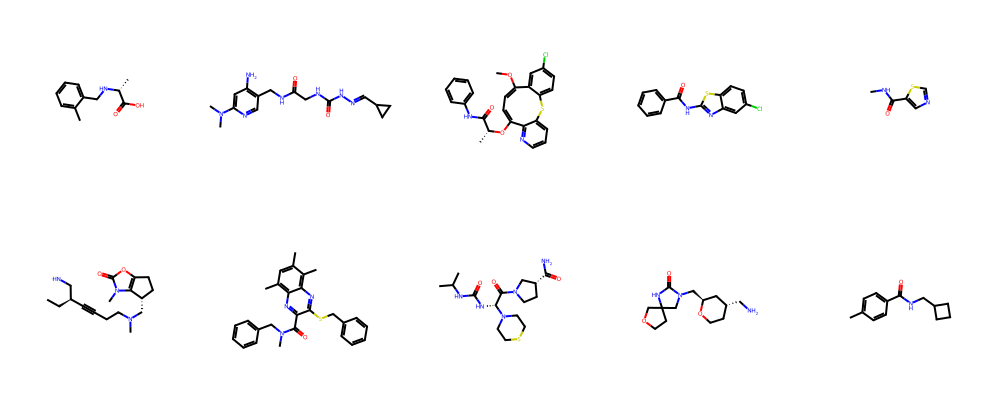

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

...

[12:08:25] UFFTYPER: Unrecognized atom type: S_5+4 (28)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None

In [7]:
# read molecules from file
# has columns: smiles, MW, LogP, TPSA
df = pd.read_csv('CVAE_transformer_300k_test.txt')



ms = [Chem.MolFromSmiles(s) for s in df['smiles']]
def avg_mv(mols):
    return sum([ExactMolWt(m) for m in mols])/len(mols)


samples = 10


def draw_samples(mols: list, samples: int) -> None:
    sample_mols = rnd.sample(mols, samples)
    img = Draw.MolsToGridImage(sample_mols, molsPerRow=5, subImgSize=(200, 200))
    display(img)



def draw_3d_samples(mols: list, samples: int) -> None:
    sample_mols = rnd.sample(mols, samples)
    for mol in sample_mols:
        # add hydrogens and embed the molecule in 3D space
        mol = Chem.AddHs(mol)
        AllChem.EmbedMolecule(mol)
        # optimize the molecule
        # for better visualization
        AllChem.MMFFOptimizeMolecule(mol)
        view = dmol.view(width=400, height=400)
        view.addModel(Chem.MolToMolBlock(mol), 'sdf')
        view.setStyle({'stick': {}})
        view.zoomTo()
        display(view.show())


draw_samples(ms, samples)

draw_3d_samples(ms, samples)



In [27]:

from __future__ import annotations

from typing import Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd

from rdkit import Chem, DataStructs
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import rdFingerprintGenerator


def safe_mol_from_smiles(smiles: str) -> Optional[Chem.Mol]:
    """
    Parse a SMILES into an RDKit Mol.
    Returns None if parsing or sanitization fails.
    """
    if smiles is None:
        return None
    s = str(smiles).strip()
    if len(s) == 0:
        return None
    try:
        mol = Chem.MolFromSmiles(s, sanitize=True)
        return mol
    except Exception:
        return None
def fpgen_fp_size(fpgen) -> int:
    """
    RDKit fingerprint generators expose options that include fpSize.
    This is the correct fixed length for ExplicitBitVect and dense count vectors.
    """
    try:
        return int(fpgen.GetOptions().fpSize)
    except Exception:
        # Fallback: make one fingerprint and query its size
        m = Chem.MolFromSmiles("CC")
        fp = fpgen.GetFingerprint(m)
        return int(fp.GetNumBits())


def safe_canonical_smiles(mol: Chem.Mol) -> Optional[str]:
    """
    Canonical SMILES for a valid RDKit Mol. Returns None on failure.
    """
    if mol is None:
        return None
    try:
        return Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)
    except Exception:
        return None


def safe_murcko_scaffold_smiles(mol: Chem.Mol) -> Optional[str]:
    """
    Murcko scaffold SMILES for a valid RDKit Mol.
    Returns None if scaffold extraction fails (common for weird structures).
    """
    if mol is None:
        return None
    try:
        scaf = MurckoScaffold.GetScaffoldForMol(mol)
        if scaf is None:
            return None
        # Canonical scaffold smiles
        return Chem.MolToSmiles(scaf, isomericSmiles=False, canonical=True)
    except Exception:
        return None


def morgan_fp(morgan_gen,mol: Chem.Mol, radius: int = 2, n_bits: int = 2048) -> Optional[DataStructs.ExplicitBitVect]:
    """
    Morgan fingerprint as an RDKit ExplicitBitVect.
    Returns None if mol is None.
    """
    if mol is None:
        return None
    # Using Morgan bit vector is standard for Tanimoto similarity
    return morgan_gen.GetFingerprint(mol)


def mol_to_fp_array(fpgen, mol: Chem.Mol, *, use_counts: bool = False, dtype=np.int8) -> Optional[np.ndarray]:
    """
    Convert an RDKit mol to a numpy fingerprint array of shape (fpSize,).

    If use_counts=False:
        uses GetFingerprint(mol) -> ExplicitBitVect -> values in {0,1}

    If use_counts=True:
        uses GetCountFingerprint(mol) -> UIntSparseIntVect (dense-exported) -> nonnegative integer counts
        dtype should then be something like np.int16 or np.int32.
    """
    if mol is None:
        return None

    n_bits = int(fpgen.GetOptions().fpSize)#fpgen_fp_size(fpgen)

    if not use_counts:
        fp = fpgen.GetFingerprint(mol)  # ExplicitBitVect, length n_bits
        arr = np.zeros((n_bits,), dtype=dtype)
        DataStructs.ConvertToNumpyArray(fp, arr)
        return arr

    # Count fingerprints: values can exceed 1, so do not use int8 unless one is shure
    fp = fpgen.GetCountFingerprint(mol)  # count vector, fixed length n_bits in the new generator API
    arr = np.zeros((n_bits,), dtype=dtype)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

def smiles_list_to_fp_matrix(
    fpgen,
    smiles_list: List[str],
    *,
    use_counts: bool = False,
    dtype=np.int8,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Convert list of SMILES to (X, valid_mask).
    X has shape [num_valid, fpSize].
    valid_mask has shape [len(smiles_list)] and indicates which were valid.
    """
    #n_bits = fpgen_fp_size(fpgen)
    n_bits = int(fpgen.GetOptions().fpSize)
    fps = []
    valid_mask = np.zeros((len(smiles_list),), dtype=bool)

    for i, s in enumerate(smiles_list):
        mol = safe_mol_from_smiles(s)
        if mol is None:
            continue
        arr = mol_to_fp_array(fpgen, mol, use_counts=use_counts, dtype=dtype)
        if arr is None:
            continue
        fps.append(arr)
        valid_mask[i] = True

    if len(fps) == 0:
        return np.zeros((0, n_bits), dtype=dtype), valid_mask

    X = np.vstack(fps)
    return X, valid_mask


def chunked_max_tanimoto(
    morgan_gen,
    query_fps: List,
    ref_fps: List,
    chunk_size: int = 5000,
) -> np.ndarray:
    """
    For each query fingerprint, compute the maximum Tanimoto similarity
    to any fingerprint in ref_fps.

    Note: If ref_fps is huge, this can still be very expensive.
     (for example 10k to 50k molecules is reasonable...)
     This is since complexity is O(len(query_fps) * len(ref_fps)) and BulkTanimotoSimilarity is fast but not that fast.
     (fast is constant factor, but the O() is still quadratic in the number of molecules...)

    tanimoto sim is: IOU = (A cap B) / (A cup B) = (A and B) / (A or B)

    args:
        morgan_gen: RDKit Morgan fingerprint generator, passed in to avoid re-creating it multiple times.
        query_fps: List of RDKit ExplicitBitVect fingerprints for the query molecules.
        ref_fps: List of RDKit ExplicitBitVect fingerprints for the reference molecules.
        chunk_size: Number of query_fps to process at once to manage memory and speed.

    returns: 
        np.ndarray of shape (len(query_fps),) with the max Tanimoto similarity to ref_fps for each query_fp.

    """
    len_query = len(query_fps)
    if len(ref_fps) == 0:
        return np.full((len_query,), np.nan, dtype=np.float32)

    out = np.empty((len_query,), dtype=np.float32)

    # Pre-store ref_fps as list, BulkTanimotoSimilarity is implemented in C++ and is fast
    # for i0 in range of query_fps with step chunk_size, compute similarities to all ref_fps and take max for each query_fp in the chunk
    print_every = 2500
    # i0 is the start index of the chunk, i1 is the end index (exclusive)
    for i0 in range(0, len_query, chunk_size):
        i1 = min(i0 + chunk_size, len_query)
        for j, qfp in enumerate(query_fps[i0:i1]):
            if (i0 + j) % print_every == 0:
                print(f"Computing similarity for query fingerprint {i0 + j} of {len_query}")
            sims = DataStructs.BulkTanimotoSimilarity(qfp, ref_fps)
            out[i0 + j] = float(max(sims)) if len(sims) > 0 else np.nan

    return out


def postprocess_and_save(
    #morgan_gen,
    gen_df: pd.DataFrame,
    ref_mols: List[Chem.Mol] | pd.DataFrame,
    out_csv_path: str,
    gen_max: int = 50_000,
    ref_max: int = 30000,
    radius: int = 2,
    n_bits: int = 2048,
    random: bool = True,
    rand_seed: int = 42,
) -> pd.DataFrame:
    """
    Postprocess generated SMILES and save results to CSV.
    Returns the processed DataFrame.
    Needs to be random selection of results since the result file is for each of the 10*10 generation sweeps.
    Just choosing the first n:k molecules would be biased since the sampling is done by linspace of MW and LogP. 
    Has both random and deterministic options for selecting reference molecules for similarity calculation.

    ref_max limits how many reference molecules are used for similarity. This is a limit of 
    runtime and memory for the similarity calculation, which is O(len(gen_df) * ref_max) in the worst case.

    args:
        gen_df: DataFrame with at least a 'smiles' column for the generated molecules
        ref_mols: List of RDKit Mol objects for the reference molecules to compare against.
        out_csv_path: Path to save the output CSV with postprocessed results.
        gen_max: Maximum number of generated molecules to process (for runtime management).
        ref_max: Maximum number of reference molecules to use for similarity (for runtime management).
            radius: Radius for Morgan fingerprint.
            n_bits: Number of bits for Morgan fingerprint.
            random: Whether to randomly select reference molecules if ref_mols is larger than ref_max.
            rand_seed: Random seed for reproducibility if random selection is used.



    """
    # NOTE: WIll be reused by a bunch of diffrent functions, so we create it here and pass it in.
    mg_gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    # Build a reference set (cap size to keep runtime sane)
    if isinstance(ref_mols, pd.DataFrame):
        orig_ref = ref_mols.copy()
        ref_mols = ref_mols['mol'].tolist()
    
    ref_mols_valid = [m for m in ref_mols if m is not None]
    len_train = len(ref_mols)
    num_valid = len(ref_mols_valid)
    print(f"Number of valid reference molecules: {num_valid}, filtered out of {len_train} total reference molecules.")
  

   

    if len(ref_mols_valid) > ref_max:
        # deterministic subset to avoid importing random; one can randomize if desired
        if random:
            rnd.seed(rand_seed)
            rnd.shuffle(ref_mols_valid)
            # choose the first ref_max after shuffling
            ref_mols_valid = ref_mols_valid[:ref_max]
        else:
            ref_mols_valid = ref_mols_valid[:ref_max]
    
    if len(gen_df) > gen_max:
        if random:
            gen_df = gen_df.sample(n=gen_max, random_state=rand_seed).reset_index(drop=True)
            gen_df = gen_df.iloc[:gen_max]
        else:
            gen_df = gen_df.iloc[:gen_max]

 

    
    ref_fps = [morgan_fp(mg_gen, m, radius=radius, n_bits=n_bits) for m in ref_mols_valid]
    ref_fps = [fp for fp in ref_fps if fp is not None]

    smiles_list = gen_df["smiles"].astype(str).tolist()

    mols: List[Optional[Chem.Mol]] = []
    canon: List[Optional[str]] = []
    scaff: List[Optional[str]] = []
    fps = []

    len_smiles = len(smiles_list)

    print(f"Processing {len_smiles} generated molecules...")

    print_every = 10_000
    # Parse and featurize
    for i, s in enumerate(smiles_list):
        if i % print_every == 0:
            print(f"Processing molecule {i} of {len_smiles}")
        mol = safe_mol_from_smiles(s)
        mols.append(mol)

        c = safe_canonical_smiles(mol)
        canon.append(c)

        sc = safe_murcko_scaffold_smiles(mol)
        scaff.append(sc)

        fp = morgan_fp(mg_gen, mol, radius=radius, n_bits=n_bits)
        fps.append(fp)

    print("Finished parsing and featurizing generated molecules.")
    is_valid = [m is not None for m in mols]

    # Similarity only for valid molecules (keeps BulkTanimotoSimilarity clean)
    valid_idx = [i for i, ok in enumerate(is_valid) if ok]
    valid_fps = [fps[i] for i in valid_idx if fps[i] is not None]

    
    print(f"Computing Tanimoto similarity of {len(valid_fps)} valid generated mols")
    # chunks must divide the valid_fps, otherwise last chunck need to be smaller
    chunk_s = 5000
    if len(valid_fps) % chunk_s != 0:
        print(f"Warning: chunk_size {chunk_s} does not divide the number of valid fingerprints {len(valid_fps)}. The last chunk will be smaller.")
    max_sim_valid = chunked_max_tanimoto(mg_gen,valid_fps, ref_fps, chunk_size=chunk_s)

    len_gen = len(gen_df)
    # Scatter back into full-length array
    print("converting back into full-length array...")
    max_sim = np.full((len_gen,), np.nan, dtype=np.float32)
    k = 0

    for i in valid_idx:
        if i % print_every == 0:
            print(f"Scattering similarity for molecule {i} of {len_gen}")
        if fps[i] is None:
            continue
        max_sim[i] = max_sim_valid[k]
        k += 1

    out_df = gen_df.copy()
    out_df["is_valid"] = is_valid
    out_df["canonical_smiles"] = canon
    out_df["murcko_scaffold_smiles"] = scaff
    out_df["tanimoto_max_to_ref"] = max_sim

    out_df.to_csv(out_csv_path, index=False)
    print(f"Saved postprocessed results to {out_csv_path}")
    return out_df





In [ ]:

# will take amount_to_process random molecules
# of both the generated and reference molecules....
amount_to_process = 50_000

train_df = pd.DataFrame({
    'smiles': smiles_list,
    'MW': [prop[0] for prop in properties_list],
    'LogP': [prop[1] for prop in properties_list]
})
train_smiles = train_df['smiles'].tolist()
train_mols = [Chem.MolFromSmiles(s) for s in train_smiles]


processed = postprocess_and_save(gen_df=gen_df,gen_max=amount_to_process,ref_max=amount_to_process, ref_mols=train_mols, out_csv_path="generated_subset_with_similarity.csv")

Number of valid reference molecules: 249455, filtered out of 249455 total reference molecules.
Processing 50000 generated molecules...
Processing molecule 0 of 50000
Processing molecule 10000 of 50000
Processing molecule 20000 of 50000
Processing molecule 30000 of 50000
Processing molecule 40000 of 50000
Finished parsing and featurizing generated molecules.
Computing Tanimoto similarity of 50000 valid generated mols
Computing similarity for query fingerprint 0 of 50000


In [19]:








from sklearn.manifold import TSNE
from sklearn.decomposition import PCA


def distribution_avg_tanimoto(df: pd.DataFrame, title_str: str = "Average Tanimoto Similarity Distribution"):
    plt.figure(figsize=(8, 5))
    plt.hist(df['tanimoto_max_to_ref'], bins=100, alpha=1.0, color="#01FF22")
    # add trend line
    plt.title(title_str)
    plt.xlabel('Max Tanimoto Similarity to train Set')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig(save_folder + run_name + "/tanimoto_similarity_distribution.png")
    plt.show()



csv_path = "generated_subset_with_similarity.csv"
processed_df = pd.read_csv(csv_path)



In [ ]:
# =============================================================================
# Train vs Generated: PCA (2D) and t-SNE (2D) on Morgan fingerprints
#
# Assumptions:
# - train_df has column "smiles"
# - processed_df has column "smiles" and optionally "canonical_smiles"
# - processed_df optionally has column "tanimoto_max_to_ref" (float in [0,1])
# =============================================================================
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from rdkit.Chem import rdFingerprintGenerator


# -------------------------
# Config
# -------------------------
rand_num = 42
n_train = 10_000
n_gen = 10_000

radius = 2
fp_size = 2048

pca_pre_dim = 50          # preprojection dimension before t-SNE
tsne_perplexity = 30      # typical range: 5 to 50, must be < n_samples
tsne_alpha = 0.5 # point transparency for t-SNE plot
point_size = 6 # point size for scatter plots


# -------------------------
# Sample SMILES
# -------------------------
train_smiles_sample = train_df["smiles"].sample(
    n=min(n_train, len(train_df)),
    random_state=rand_num
).tolist()

gen_smiles_col = "canonical_smiles" if "canonical_smiles" in processed_df.columns else "smiles"
gen_sample_df = processed_df.sample(
    n=min(n_gen, len(processed_df)),
    random_state=rand_num
).copy()

gen_smiles_sample = gen_sample_df[gen_smiles_col].tolist()
gen_tanimoto = (
    gen_sample_df["tanimoto_max_to_ref"].to_numpy(dtype=float)
    if "tanimoto_max_to_ref" in gen_sample_df.columns else None
)


# -------------------------
# Fingerprints -> matrices
# -------------------------
mp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=fp_size)

X_train, train_valid_mask = smiles_list_to_fp_matrix(
    mp_gen, train_smiles_sample, use_counts=False, dtype=np.int8
)
X_gen, gen_valid_mask = smiles_list_to_fp_matrix(
    mp_gen, gen_smiles_sample, use_counts=False, dtype=np.int8
)

# Keep tanimoto aligned with *valid* generated rows only
if gen_tanimoto is not None:
    gen_tanimoto = gen_tanimoto[gen_valid_mask]

print("Train valid:", X_train.shape[0], "of", len(train_smiles_sample))
print("Gen valid:", X_gen.shape[0], "of", len(gen_smiles_sample))

if X_train.shape[0] == 0 or X_gen.shape[0] == 0:
    raise RuntimeError("No valid molecules found in train or generated sample. Check SMILES parsing.")

# Combine for shared embedding space (train first, then gen)
X_all = np.vstack([X_train, X_gen])

# Class labels for coloring (0=train, 1=generated)
y_class = np.concatenate([
    np.zeros((X_train.shape[0],), dtype=np.int32),
    np.ones((X_gen.shape[0],), dtype=np.int32),
])


# -------------------------
# Make sure output folder exists
# -------------------------
out_dir = os.path.join(save_folder, run_name)
os.makedirs(out_dir, exist_ok=True)


# -------------------------
# PCA (2D) visualization
# -------------------------
pca_vis = PCA(n_components=2, random_state=rand_num)
X_pca_2d = pca_vis.fit_transform(X_all)

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    X_pca_2d[:, 0], X_pca_2d[:, 1],
    s=point_size, alpha=0.7, c=y_class
)
plt.colorbar(sc, label="Class (0=train, 1=generated)")
plt.title("PCA (2D) on Morgan fingerprints colored by Class")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "pca2_train_vs_generated.png"), dpi=200)
plt.show()


# -------------------------
# PCA-50 preprojection then t-SNE (2D)
# Note: when you already preproject with PCA, prefer init='random' in sklearn TSNE.
# -------------------------
pca_pre = PCA(n_components=pca_pre_dim, random_state=rand_num)
X_pca_pre = pca_pre.fit_transform(X_all)

# Perplexity must be < n_samples, and practically should be smaller than about n_samples/3
n_total = X_pca_pre.shape[0]
if tsne_perplexity >= n_total:
    raise ValueError(f"t-SNE perplexity ({tsne_perplexity}) must be < number of samples ({n_total}).")

tsne = TSNE(
    n_components=2,
    random_state=rand_num,
    perplexity=tsne_perplexity,
    init="random",
    learning_rate="auto",
)
X_tsne = tsne.fit_transform(X_pca_pre)

# Split back to train/gen
train_tsne = X_tsne[: X_train.shape[0]]
gen_tsne = X_tsne[X_train.shape[0] :]

# Plot: train vs generated (two colors, with legend)
plt.figure(figsize=(8, 6))
plt.scatter(train_tsne[:, 0], train_tsne[:, 1], s=point_size, alpha=tsne_alpha, label="Train")
plt.scatter(gen_tsne[:, 0], gen_tsne[:, 1], s=point_size, alpha=tsne_alpha, label="Generated")
plt.legend()
plt.title(f"t-SNE on Morgan fingerprints (PCA-{pca_pre_dim} preprojection)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "tsne_train_vs_generated.png"), dpi=200)
plt.show()


# -------------------------
# Plot: generated colored by tanimoto_max_to_ref (optional)
# -------------------------
if gen_tanimoto is not None:
    if gen_tanimoto.shape[0] != gen_tsne.shape[0]:
        raise ValueError(
            "gen_tanimoto and gen_tsne are misaligned after validity filtering. "
            f"gen_tanimoto: {gen_tanimoto.shape[0]}, gen_tsne: {gen_tsne.shape[0]}"
        )

    plt.figure(figsize=(8, 6))
    sc = plt.scatter(
        gen_tsne[:, 0], gen_tsne[:, 1],
        s=point_size, alpha=0.85, c=gen_tanimoto,
        vmin=0.0, vmax=1.0
    )
    plt.colorbar(sc, label="Max Tanimoto to train")
    plt.title("Generated t-SNE colored by max Tanimoto to train")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "tsne_generated_colored_by_tanimoto.png"), dpi=200)
    plt.show()

AttributeError: 'FingerprintGenerator64' object has no attribute 'GetDefaultFPSize'